# Acceleration & Gyro Analysis — Full Flight

Load the high-rate Blue Raven data and plot **acceleration** and **gyroscope** readings over the entire flight.

In [24]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import pandas as pd
import matplotlib.pyplot as plt
from path_config import default_hr_csv

# Load the high-rate CSV
hr_csv = default_hr_csv()
df = pd.read_csv(hr_csv)

print(f"Loaded: {hr_csv.name}")
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Loaded: SnowbirdPrim HR_03-21-2026_10_52_17.csv
Rows: 168,680  |  Columns: ['Year', 'Month', 'Day', 'Time', 'Flight_Time_(s)', 'Sync', 'Gyro_X', 'Gyro_Y', 'Gyro_Z', 'Accel_X', 'Accel_Y', 'Accel_Z', 'Quat_1', 'Quat_2', 'Quat_3', 'Quat_4', 'Aux_Volts', 'Current']


,Year,Month,Day,Time,Flight_Time_(s),Sync,Gyro_X,Gyro_Y,Gyro_Z,Accel_X,Accel_Y,Accel_Z,Quat_1,Quat_2,Quat_3,Quat_4,Aux_Volts,Current
0,2026,3,21,10:52:15.262,-2.026,29,0.0,0.0,0.0,1.00,0.00,0.0,1.0,0.0,0.0,0.0,0.034,0.0
1,2026,3,21,10:52:15.264,-2.024,31,0.0,0.0,0.0,0.99,-0.01,0.0,1.0,0.0,0.0,0.0,0.036,0.0
2,2026,3,21,10:52:15.266,-2.022,33,-0.2,-0.2,0.0,0.99,0.00,0.0,1.0,0.0,0.0,0.0,0.034,0.0
3,2026,3,21,10:52:15.268,-2.020,35,-0.1,0.1,0.2,0.99,-0.01,0.0,1.0,0.0,0.0,0.0,0.036,0.0
4,2026,3,21,10:52:15.270,-2.018,37,0.0,0.0,0.0,0.99,-0.01,0.0,1.0,0.0,0.0,0.0,0.036,0.0


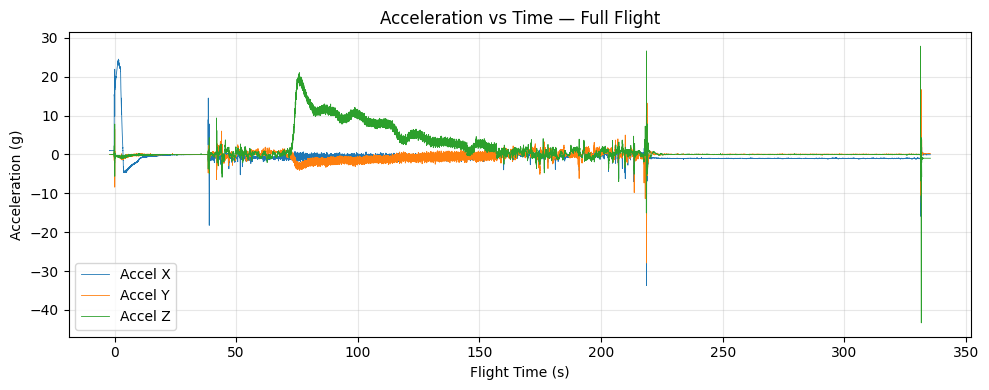

In [25]:
t = df["Flight_Time_(s)"]

# --- Acceleration vs Time ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, df["Accel_X"], label="Accel X", linewidth=0.6)
ax.plot(t, df["Accel_Y"], label="Accel Y", linewidth=0.6)
ax.plot(t, df["Accel_Z"], label="Accel Z", linewidth=0.6)
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Acceleration (g)")
ax.set_title("Acceleration vs Time — Full Flight")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

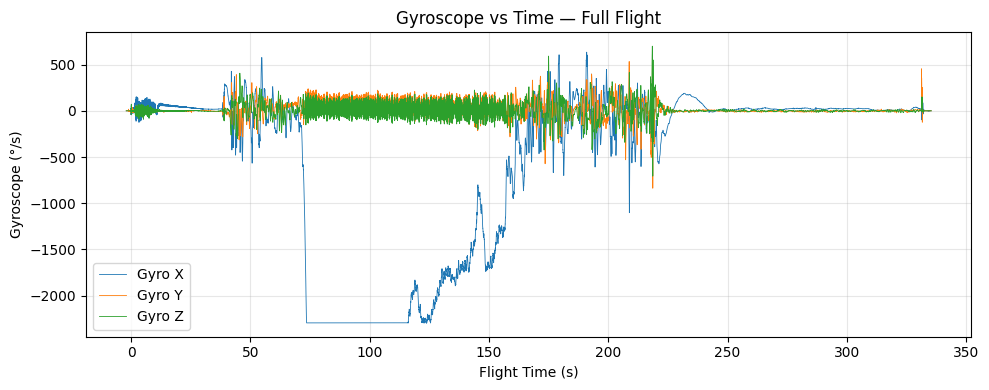

In [26]:
# --- Gyroscope vs Time ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, df["Gyro_X"], label="Gyro X", linewidth=0.6)
ax.plot(t, df["Gyro_Y"], label="Gyro Y", linewidth=0.6)
ax.plot(t, df["Gyro_Z"], label="Gyro Z", linewidth=0.6)
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Gyroscope (°/s)")
ax.set_title("Gyroscope vs Time — Full Flight")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Zoomed: First 50 Seconds (Ascent → Drogue Deployment)

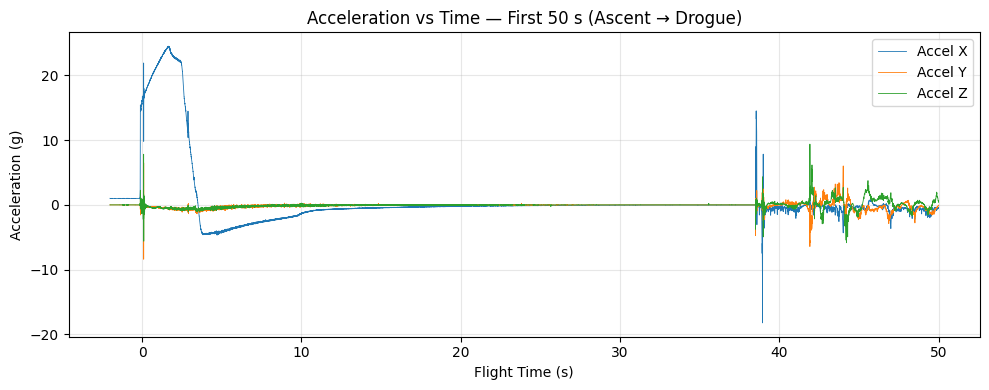

In [27]:
# Filter to first 50 seconds
mask = t <= 50
t_z = t[mask]

# --- Acceleration (0–50 s) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_z, df.loc[mask, "Accel_X"], label="Accel X", linewidth=0.6)
ax.plot(t_z, df.loc[mask, "Accel_Y"], label="Accel Y", linewidth=0.6)
ax.plot(t_z, df.loc[mask, "Accel_Z"], label="Accel Z", linewidth=0.6)
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Acceleration (g)")
ax.set_title("Acceleration vs Time — First 50 s (Ascent → Drogue)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

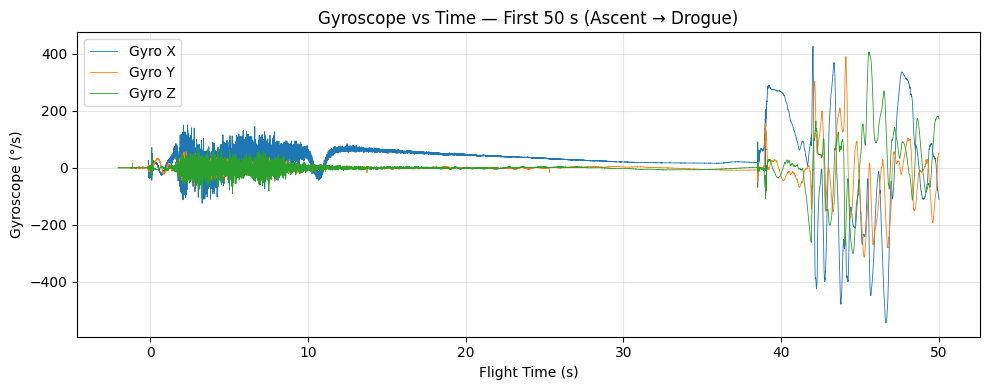

In [28]:
# --- Gyroscope (0–50 s) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_z, df.loc[mask, "Gyro_X"], label="Gyro X", linewidth=0.6)
ax.plot(t_z, df.loc[mask, "Gyro_Y"], label="Gyro Y", linewidth=0.6)
ax.plot(t_z, df.loc[mask, "Gyro_Z"], label="Gyro Z", linewidth=0.6)
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Gyroscope (°/s)")
ax.set_title("Gyroscope vs Time — First 50 s (Ascent → Drogue)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Zoomed: First 15 Seconds (Launch → Motor Burn → Coast)

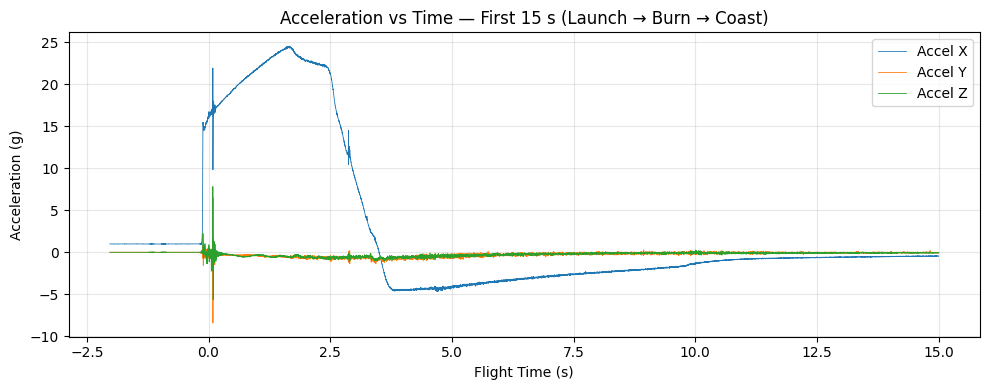

In [29]:
# Filter to first 15 seconds
mask15 = t <= 15
t15 = t[mask15]

# --- Acceleration (0–15 s) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t15, df.loc[mask15, "Accel_X"], label="Accel X", linewidth=0.6)
ax.plot(t15, df.loc[mask15, "Accel_Y"], label="Accel Y", linewidth=0.6)
ax.plot(t15, df.loc[mask15, "Accel_Z"], label="Accel Z", linewidth=0.6)
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Acceleration (g)")
ax.set_title("Acceleration vs Time — First 15 s (Launch → Burn → Coast)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

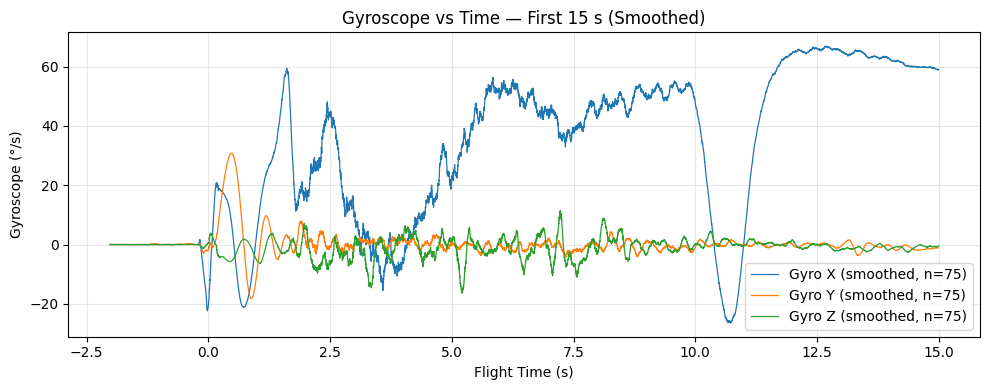

In [30]:
# --- Gyroscope (0–15 s, smoothed) ---
# Use a short moving-average window (~50 ms) to reduce sensor noise
# while keeping launch/burn/coast dynamics visible.
dt = float(t15.diff().median())
window_s = 0.15
window_n = max(3, int(round(window_s / dt)))
if window_n % 2 == 0:
    window_n += 1

gyro_x_s = df.loc[mask15, "Gyro_X"].rolling(window=window_n, center=True, min_periods=1).mean()
gyro_y_s = df.loc[mask15, "Gyro_Y"].rolling(window=window_n, center=True, min_periods=1).mean()
gyro_z_s = df.loc[mask15, "Gyro_Z"].rolling(window=window_n, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t15, gyro_x_s, label=f"Gyro X (smoothed, n={window_n})", linewidth=0.9)
ax.plot(t15, gyro_y_s, label=f"Gyro Y (smoothed, n={window_n})", linewidth=0.9)
ax.plot(t15, gyro_z_s, label=f"Gyro Z (smoothed, n={window_n})", linewidth=0.9)
ax.set_xlabel("Flight Time (s)")
ax.set_ylabel("Gyroscope (°/s)")
ax.set_title("Gyroscope vs Time — First 15 s (Smoothed)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()